# Exoplanet Habitability Zone Analysis

This notebook performs Exploratory Data Analysis (EDA), computes planetary habitability and the Earth Similarity Index (ESI) on `Data_Gold_Layer.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Load dataset
csv_path = r"c:\Users\nourh\Downloads\depi\Medallion Architecture\Gold Layer\Data_Gold_Layer.csv"
df = pd.read_csv(csv_path)

# Calc missings
df.isnull().sum()

pl_name                 0
planet_id               0
star_name               0
star_id                 0
discoverymethod         0
discovery_id            0
disc_year_x             1
Date_id                 0
Star_Name               0
Star Temperature        0
Star Radius             0
Stellar Mass            0
Stellar Luminosity      0
System_Distance       100
Parallax              208
No_of_Stars             0
Is binary               0
Method                  0
Year                    1
PlanetName              0
Planet numbers          0
orbital period          1
Semi_major axis         1
Eccentricity           57
Radius                  0
Mass                    0
Density                 0
Temperature             1
Flux                    1
disc_year_y             1
dtype: int64

In [2]:
# Impute missing values
df['Temperature'] = df['Temperature'].fillna(df['Temperature'].median())
df['Flux'] = df['Flux'].fillna(df['Flux'].median())
df['Eccentricity'] = df['Eccentricity'].fillna(0.0)
df['System_Distance'] = df['System_Distance'].fillna(df['System_Distance'].median())
df['Parallax'] = df['Parallax'].fillna(df['Parallax'].median())

print(f"Dataset Shape: {df.shape}")
df.head(3)

Dataset Shape: (5878, 30)


,pl_name,planet_id,star_name,star_id,discoverymethod,discovery_id,disc_year_x,Date_id,Star_Name,Star Temperature,...,Planet numbers,orbital period,Semi_major axis,Eccentricity,Radius,Mass,Density,Temperature,Flux,disc_year_y
0,11 Com b,0,11 Com,0,Radial Velocity,0,2007.0,0,11 Com,4874.0,...,1,0.884901,1.178,0.238,3215.668419,4914.898486,8.140000e-07,803.218264,69.084121,2007.0
1,11 UMi b,1,11 UMi,1,Radial Velocity,1,2009.0,1,11 UMi,4213.0,...,1,1.413333,1.530,0.080,3054.089914,4684.814200,9.060000e-07,896.380652,107.155343,2009.0
2,14 And b,2,14 And,2,Radial Velocity,2,2008.0,2,14 And,4888.0,...,1,0.511321,0.775,0.000,662.607527,1131.151301,2.140000e-05,909.877272,113.756233,2008.0


In [3]:
df.isnull().sum()

pl_name               0
planet_id             0
star_name             0
star_id               0
discoverymethod       0
discovery_id          0
disc_year_x           1
Date_id               0
Star_Name             0
Star Temperature      0
Star Radius           0
Stellar Mass          0
Stellar Luminosity    0
System_Distance       0
Parallax              0
No_of_Stars           0
Is binary             0
Method                0
Year                  1
PlanetName            0
Planet numbers        0
orbital period        1
Semi_major axis       1
Eccentricity          0
Radius                0
Mass                  0
Density               0
Temperature           0
Flux                  0
disc_year_y           1
dtype: int64

## Part 1: Scientific Calculations & Enriched Data

### 1. Habitability Zone (HZ) Criteria
- **Planetary Temperature ($T_{eq}$)**: $180\text{ K} \le T_{eq} \le 320\text{ K}$
- **Stellar Flux ($S$)**: $0.25 \le S \le 2.2$ (Earth units)
- **Rocky Planet**: Radius $R < 1.6 \text{ } R_\oplus$
- **Habitable Rocky Planet**: Meets HZ conditions AND is rocky.

### 2. Earth Similarity Index (ESI) Formula
Calculated as the 4-parameter weighted geometric mean:
$$ESI = \left[ \left(1 - \left|\frac{R - R_0}{R + R_0}\right|\right)^{0.57} \cdot \left(1 - \left|\frac{D - D_0}{D + D_0}\right|\right)^{1.07} \cdot \left(1 - \left|\frac{V_{esc} - V_0}{V_{esc} + V_0}\right|\right)^{0.70} \cdot \left(1 - \left|\frac{T_{eq} - T_0}{T_{eq} + T_0}\right|\right)^{5.58} \right]^{\frac{1}{7.92}}$$
- Reference values: $R_0 = 1.0$, $D_0 = 5.51$, $V_0 = 1.0$, $T_0 = 255.0$
- $V_{esc} = \sqrt{Mass / Radius}$ (Earth units)



In [4]:
# Escape velocity
df['Escape_Velocity'] = np.sqrt(df['Mass'] / df['Radius'])

# ESI calculation
R_ref, D_ref, V_ref, T_ref = 1.0, 5.51, 1.0, 255.0
w_R, w_D, w_V, w_T = 0.57, 1.07, 0.70, 5.58
w_sum = w_R + w_D + w_V + w_T

esi_R = (1 - np.abs((df['Radius'] - R_ref) / (df['Radius'] + R_ref))) ** w_R
esi_D = (1 - np.abs((df['Density'] - D_ref) / (df['Density'] + D_ref))) ** w_D
esi_V = (1 - np.abs((df['Escape_Velocity'] - V_ref) / (df['Escape_Velocity'] + V_ref))) ** w_V
esi_T = (1 - np.abs((df['Temperature'] - T_ref) / (df['Temperature'] + T_ref))) ** w_T

df['ESI'] = (esi_R * esi_D * esi_V * esi_T) ** (1 / w_sum)

# Habitability flags
df['is_habitable'] = (df['Flux'] >= 0.25) & (df['Flux'] <= 2.2) & (df['Temperature'] >= 180) & (df['Temperature'] <= 320)
df['is_rocky'] = df['Radius'] < 1.6
df['is_habitable_rocky'] = df['is_habitable'] & df['is_rocky']

# Save enriched dataset
enriched_csv = r"c:\Users\nourh\Downloads\depi\Medallion Architecture\Gold Layer\Data_Gold_Layer_Enriched.csv"
df.to_csv(enriched_csv, index=False)

print(f"Total Planets: {len(df)}")
print(f"Habitable Zone Planets: {df['is_habitable'].sum()}")
print(f"Rocky Planets: {df['is_rocky'].sum()}")
print(f"Habitable Rocky Planets: {df['is_habitable_rocky'].sum()}")

# Top 10 highest ESI exoplanets
df.sort_values(by='ESI', ascending=False)[['pl_name', 'Radius', 'Mass', 'Density', 'Temperature', 'Flux', 'ESI', 'is_habitable_rocky']].head(10)

Total Planets: 5878
Habitable Zone Planets: 302
Rocky Planets: 1314
Habitable Rocky Planets: 45


,pl_name,Radius,Mass,Density,Temperature,Flux,ESI,is_habitable_rocky
180,GJ 1002 b,1.021134,1.080000,5.588918,252.461669,0.674257,0.993520,True
5825,Wolf 1069 b,1.064816,1.260000,5.750404,250.113924,0.649524,0.984269,True
2787,Kepler-1649 c,1.060000,1.239155,5.732705,261.502190,0.776149,0.982874,True
5612,TRAPPIST-1 e,0.920000,0.692000,4.896595,249.771754,0.645977,0.975190,True
4917,Proxima Cen b,1.014655,1.055000,5.564783,238.472183,0.536778,0.974274,True
5625,Teegarden's Star c,1.013346,1.050000,5.559900,237.581150,0.528800,0.973124,True
5557,TOI-700 d,1.073000,1.296006,5.780420,267.799644,0.853658,0.972787,True
184,GJ 1061 d,1.143883,1.640000,6.037415,242.013919,0.569384,0.962436,True
3967,Kepler-442 b,1.340000,2.935930,6.723306,256.655429,0.720188,0.954361,True
268,GJ 667 C f,1.309840,2.700000,6.620032,262.482022,0.787848,0.950266,True


## Part 2: Dashboard Specifications & Visualizations

### Page 1: Overview & Discovery Methods
- **Objective**: Display discovery history, methods, and proximity to Earth.
- **Questions**:
  - How have discoveries evolved over time?
  - Which discovery methods are most successful?
  - What is the distance distribution of exoplanets?
  - What is the proportion of multi-star systems?
- **KPIs**:
  - Total Planets: **5,878**
  - Unique Stars: **4,332**
  - Max Distance: **2,674.3 pc** (8,718 LY)
  - Binary System Share: **9.87%**
- **Suggested Charts**:
  - *Cumulative Discoveries Over Time*: Stacked Area Chart (Year vs. Count, colored by Method).
  - *Discovery Methods Success*: Bar Chart (Method vs. Count).
  - *Distance Distribution*: Histogram (Distance vs. Frequency).
  - *Star Systems*: Donut Chart (Number of stars vs. Proportion).



Total Planets: 5878
Unique Host Stars: 4024
Max Distance: 7200.0 Parsecs
Binary Share: 8.23%


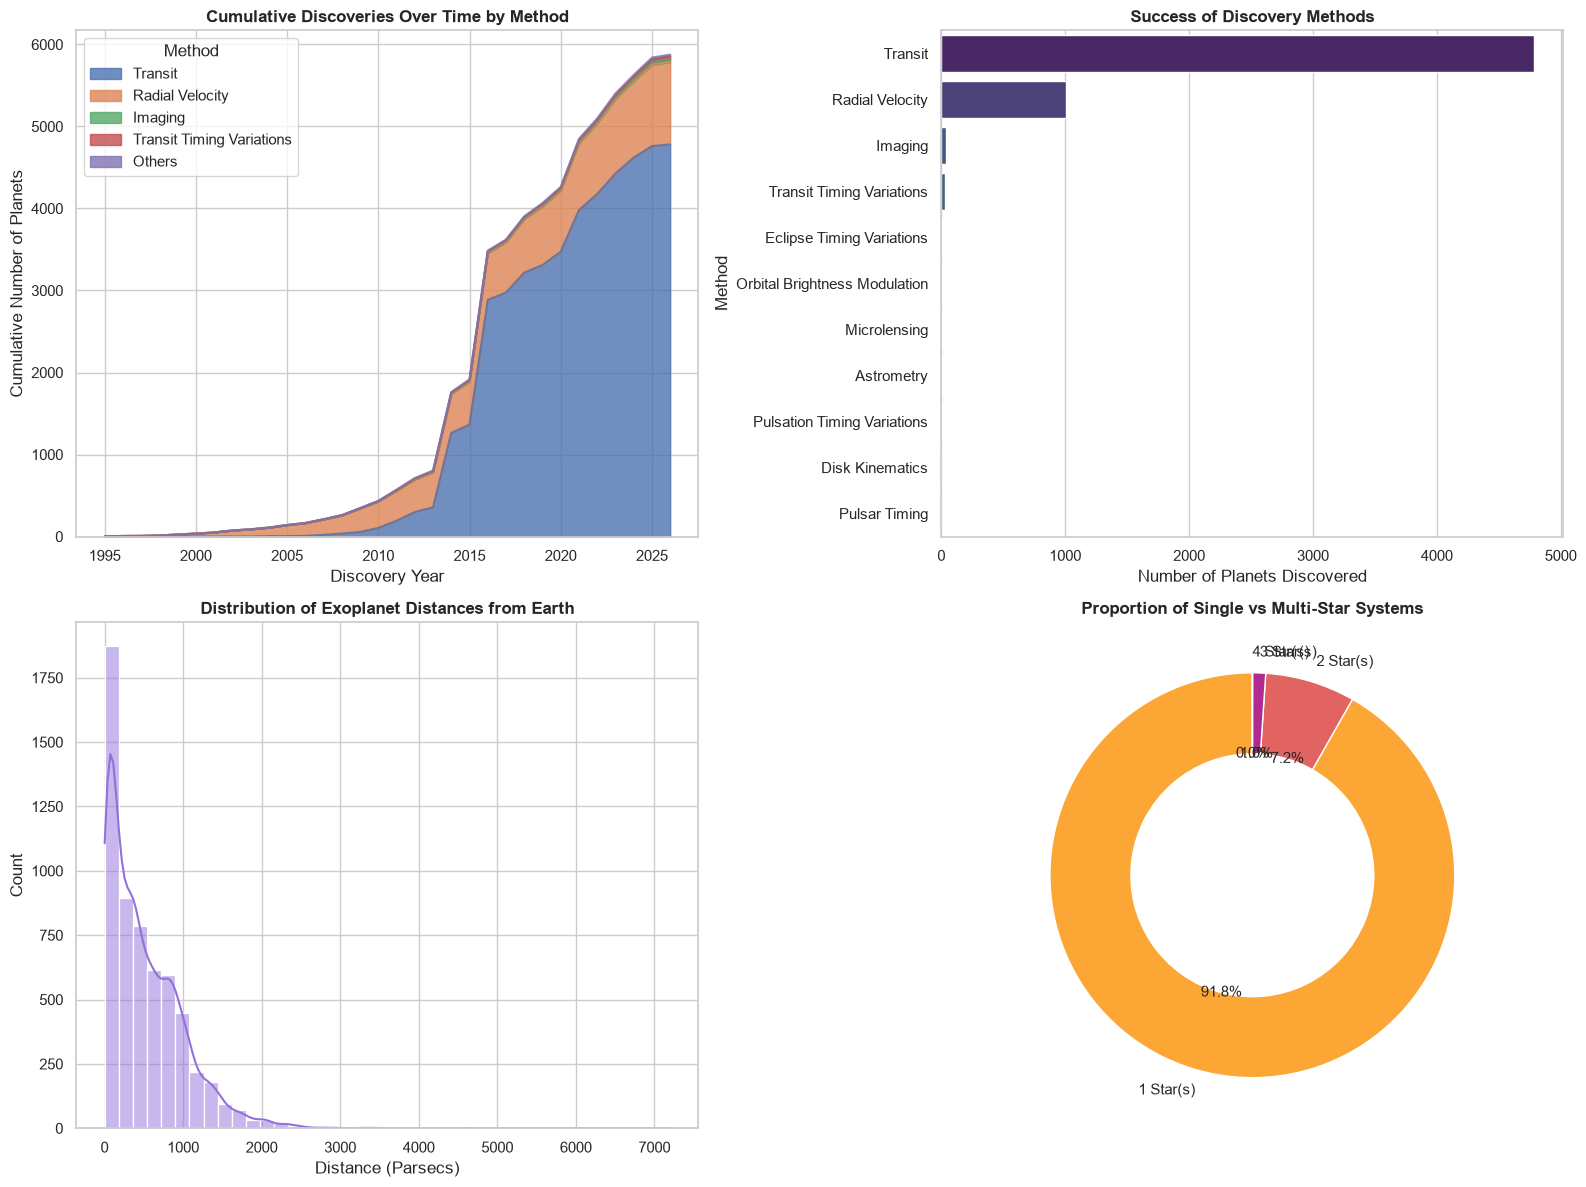

In [5]:
# KPIs
print(f"Total Planets: {len(df)}")
print(f"Unique Host Stars: {df['star_name'].nunique()}")
print(f"Max Distance: {df['System_Distance'].max():.1f} Parsecs")
print(f"Binary Share: {df['Is binary'].mean()*100:.2f}%")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cumulative Discoveries Over Time
year_method = df.groupby(['Year', 'Method']).size().unstack(fill_value=0).cumsum()
top_methods = df['Method'].value_counts().head(4).index
year_method_plot = year_method.copy()
other_cols = [c for c in year_method.columns if c not in top_methods]
if other_cols:
    year_method_plot['Others'] = year_method[other_cols].sum(axis=1)
    year_method_plot = year_method_plot[list(top_methods) + ['Others']]
else:
    year_method_plot = year_method_plot[list(top_methods)]

year_method_plot.plot(kind='area', stacked=True, ax=axes[0,0], alpha=0.8)
axes[0,0].set_title("Cumulative Discoveries Over Time by Method", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("Discovery Year")
axes[0,0].set_ylabel("Cumulative Number of Planets")

# 2. Success of Discovery Methods
method_counts = df['Method'].value_counts()
sns.barplot(x=method_counts.values, y=method_counts.index, ax=axes[0,1], palette="viridis", hue=method_counts.index, legend=False)
axes[0,1].set_title("Success of Discovery Methods", fontsize=12, fontweight='bold')
axes[0,1].set_xlabel("Number of Planets Discovered")

# 3. Distance distribution
sns.histplot(data=df, x="System_Distance", bins=40, kde=True, ax=axes[1,0], color="mediumpurple")
axes[1,0].set_title("Distribution of Exoplanet Distances from Earth", fontsize=12, fontweight='bold')
axes[1,0].set_xlabel("Distance (Parsecs)")

# 4. Donut Chart for Multi-Star Systems
star_counts = df['No_of_Stars'].value_counts()
axes[1,1].pie(star_counts.values, labels=[f"{x} Star(s)" for x in star_counts.index], autopct='%1.1f%%', 
              startangle=90, colors=sns.color_palette("plasma_r", len(star_counts)), wedgeprops=dict(width=0.4, edgecolor='w'))
axes[1,1].set_title("Proportion of Single vs Multi-Star Systems", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Page 2: Physical & Orbital Characteristics
- **Objective**: Explore exoplanet size, mass, density, orbital period, and eccentricity.
- **Questions**:
  - Does orbital period correlate with semi-major axis (Kepler's 3rd Law)?
  - What is the mass-radius relation?
  - How are eccentricity and density distributed?
- **KPIs**:
  - Avg Radius: **94.41** $R_\oplus$
  - Avg Mass: **241.48** $M_\oplus$
  - Avg Density: **5.39** $g/cm^3$
  - Avg Eccentricity: **0.120**
- **Suggested Charts**:
  - *Kepler's Third Law*: Scatter Plot (Log Semi-Major Axis vs. Log Period, colored by is_habitable).
  - *Mass vs. Radius*: Scatter Plot (Radius vs. Mass, colored by is_rocky).
  - *Eccentricity*: Histogram (Eccentricity vs. Count).
  - *Rocky vs. Gaseous Proportion*: Bar Chart (Planet Type vs. Count).



Avg Radius: 94.41 Earth Radii
Avg Mass: 241.48 Earth Masses
Avg Density: 5.39 g/cm³
Avg Eccentricity: 0.083


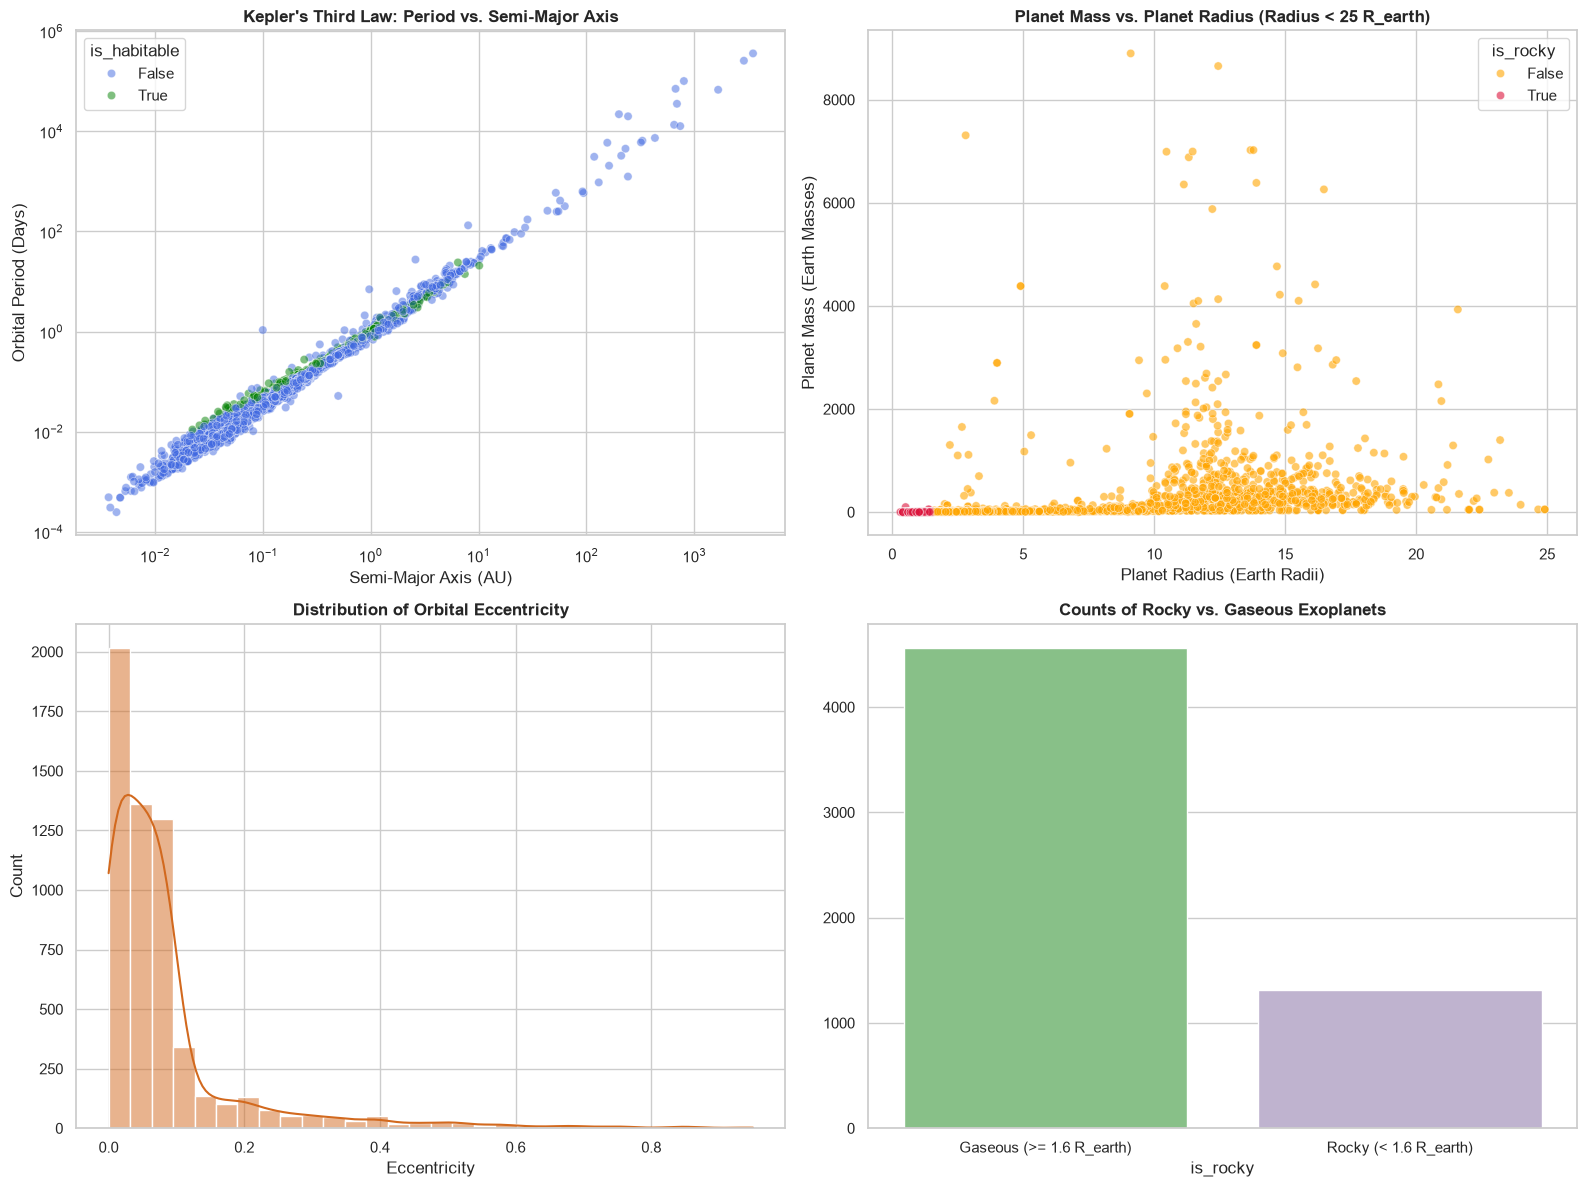

In [6]:
# KPIs
print(f"Avg Radius: {df['Radius'].mean():.2f} Earth Radii")
print(f"Avg Mass: {df['Mass'].mean():.2f} Earth Masses")
print(f"Avg Density: {df['Density'].mean():.2f} g/cm³")
print(f"Avg Eccentricity: {df['Eccentricity'].mean():.3f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Kepler's Third Law
sns.scatterplot(data=df, x="Semi_major axis", y="orbital period", hue="is_habitable", alpha=0.5, ax=axes[0,0], palette={True: "green", False: "royalblue"})
axes[0,0].set_xscale('log')
axes[0,0].set_yscale('log')
axes[0,0].set_title("Kepler's Third Law: Period vs. Semi-Major Axis", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("Semi-Major Axis (AU)")
axes[0,0].set_ylabel("Orbital Period (Days)")

# 2. Mass vs Radius (radius < 25 Earth radii)
df_clean = df[df['Radius'] < 25]
sns.scatterplot(data=df_clean, x="Radius", y="Mass", hue="is_rocky", alpha=0.6, ax=axes[0,1], palette={True: "crimson", False: "orange"})
axes[0,1].set_title("Planet Mass vs. Planet Radius (Radius < 25 R_earth)", fontsize=12, fontweight='bold')
axes[0,1].set_xlabel("Planet Radius (Earth Radii)")
axes[0,1].set_ylabel("Planet Mass (Earth Masses)")

# 3. Eccentricity Histogram
sns.histplot(data=df, x="Eccentricity", bins=30, ax=axes[1,0], color="chocolate", kde=True)
axes[1,0].set_title("Distribution of Orbital Eccentricity", fontsize=12, fontweight='bold')
axes[1,0].set_xlabel("Eccentricity")

# 4. Rocky vs Gaseous Proportions
planet_classes = df['is_rocky'].map({True: 'Rocky (< 1.6 R_earth)', False: 'Gaseous (>= 1.6 R_earth)'}).value_counts()
sns.barplot(x=planet_classes.index, y=planet_classes.values, ax=axes[1,1], palette="Accent", hue=planet_classes.index, legend=False)
axes[1,1].set_title("Counts of Rocky vs. Gaseous Exoplanets", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Page 3: Stellar Properties & Host Systems
- **Objective**: Examine host star properties and planetary system sizes.
- **Questions**:
  - What star types host exoplanets?
  - Does host star mass correlate with star temperature?
  - How are system sizes (planets per system) distributed?
- **KPIs**:
  - Avg Star Temp: **5,431.1 K**
  - Avg Stellar Mass: **0.97** $M_\odot$
  - Avg Stellar Luminosity: **1.45** $L_\odot$
  - Largest System Size: **8 planets**
- **Suggested Charts**:
  - *Stellar H-R Diagram*: Scatter Plot (Temperature inverted vs. Log Luminosity, sized by Mass).
  - *Stellar Mass vs. Temp*: Scatter Plot (Mass vs. Temperature).
  - *Planetary System Sizes*: Bar Chart (Number of planets vs. System Count).
  - *Correlation Heatmap*: Heatmap of stellar features and system sizes.



Avg Star Temp: 5377.5 K
Avg Stellar Mass: 0.97 Solar Masses
Avg Stellar Luminosity: 6.11 Solar Luminosities
Max Planets in System: 8


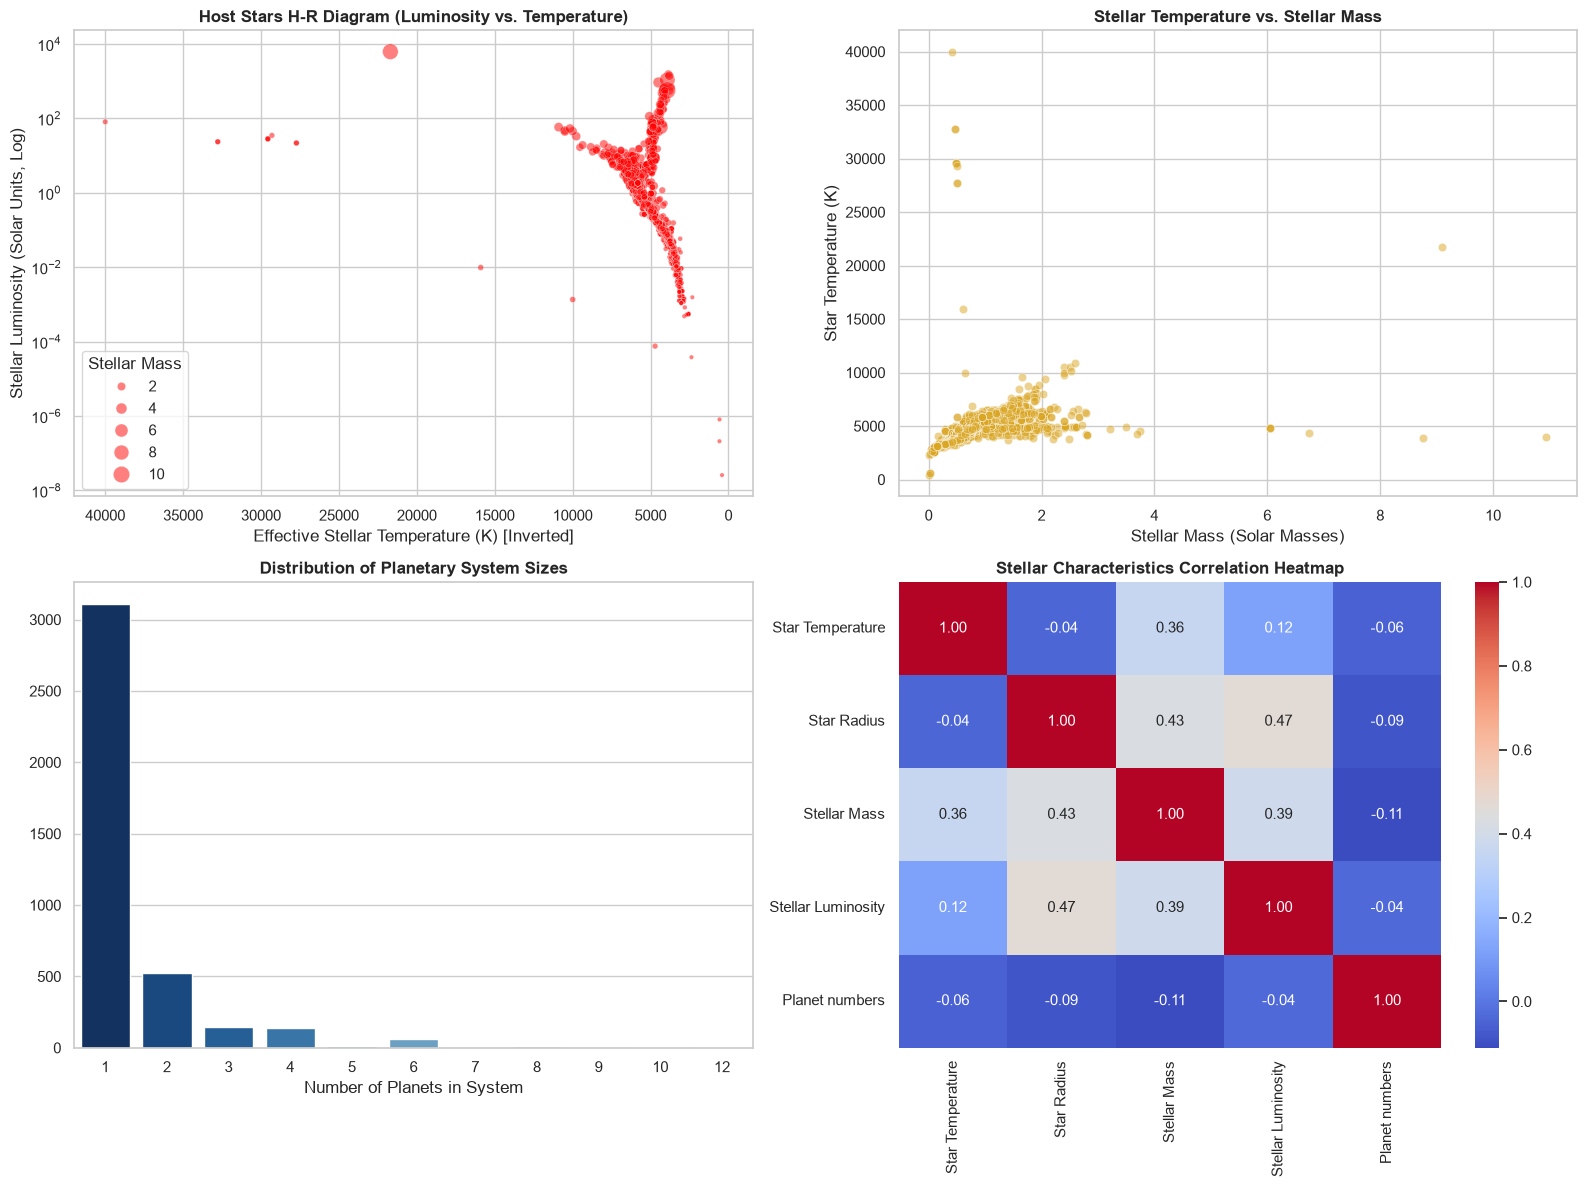

In [7]:
# KPIs
print(f"Avg Star Temp: {df['Star Temperature'].mean():.1f} K")
print(f"Avg Stellar Mass: {df['Stellar Mass'].mean():.2f} Solar Masses")
print(f"Avg Stellar Luminosity: {df['Stellar Luminosity'].mean():.2f} Solar Luminosities")
print(f"Max Planets in System: {df['Planet numbers'].max()}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Host Stars H-R Diagram
sns.scatterplot(data=df, x="Star Temperature", y="Stellar Luminosity", alpha=0.5, ax=axes[0,0], color="red", size="Stellar Mass", sizes=(10, 150))
axes[0,0].set_yscale('log')
axes[0,0].invert_xaxis()
axes[0,0].set_title("Host Stars H-R Diagram (Luminosity vs. Temperature)", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("Effective Stellar Temperature (K) [Inverted]")
axes[0,0].set_ylabel("Stellar Luminosity (Solar Units, Log)")

# 2. Stellar Temp vs Mass
sns.scatterplot(data=df, x="Stellar Mass", y="Star Temperature", alpha=0.5, ax=axes[0,1], color="goldenrod")
axes[0,1].set_title("Stellar Temperature vs. Stellar Mass", fontsize=12, fontweight='bold')
axes[0,1].set_xlabel("Stellar Mass (Solar Masses)")
axes[0,1].set_ylabel("Star Temperature (K)")

# 3. System Size Distribution
system_sizes = df.groupby('star_name')['PlanetName'].count().value_counts().sort_index()
sns.barplot(x=system_sizes.index, y=system_sizes.values, ax=axes[1,0], palette="Blues_r", hue=system_sizes.index, legend=False)
axes[1,0].set_title("Distribution of Planetary System Sizes", fontsize=12, fontweight='bold')
axes[1,0].set_xlabel("Number of Planets in System")

# 4. Correlation Heatmap
corr = df[['Star Temperature', 'Star Radius', 'Stellar Mass', 'Stellar Luminosity', 'Planet numbers']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1,1])
axes[1,1].set_title("Stellar Characteristics Correlation Heatmap", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Page 4: Habitability & Goldilocks Zone
- **Objective**: Identify habitable zone candidates and Earth-like exoplanets.
- **Questions**:
  - How many exoplanets are inside the Habitable Zone?
  - How many HZ planets are rocky?
  - Which planets have the highest ESI score and how far are they?
- **KPIs**:
  - Habitable Zone Planets: **302**
  - Habitable Rocky Planets: **45**
  - Max ESI: **0.9935** (GJ 1002 b)
  - Closest Habitable Planet: **Proxima Cen b** (1.30 pc / 4.2 LY)
- **Suggested Charts**:
  - *The Goldilocks Zone*: Scatter Plot (Log Flux vs. Temperature, with HZ shaded region).
  - *Planet Radius vs. Flux*: Scatter Plot (Log Flux vs. Log Radius, with Rocky boundary).
  - *ESI Score Distribution*: Histogram (ESI score vs. Count).
  - *Top 10 Candidates*: Horizontal Bar Chart (Planet Name vs. ESI).



Habitable Zone Planets: 302
Habitable Rocky Planets: 45
Max ESI: 0.9935
Closest Habitable Planet: Proxima Cen d at 1.30 pc


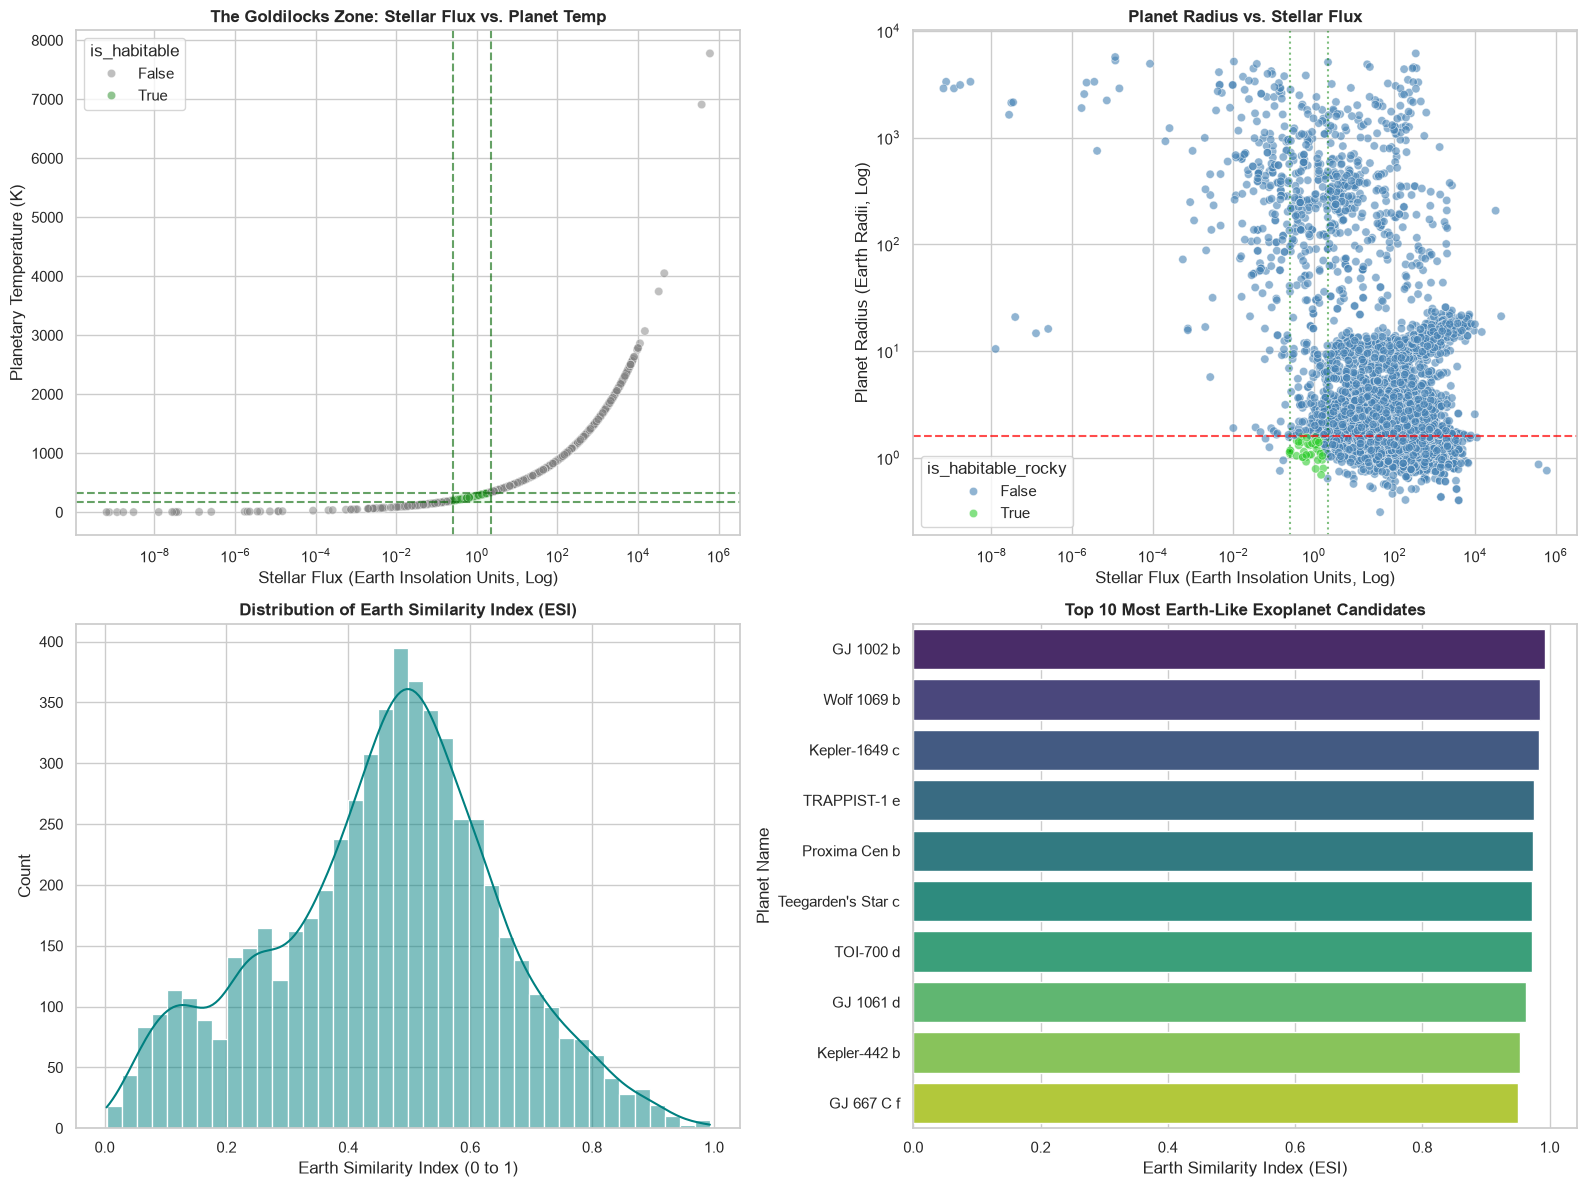

In [8]:
# KPIs
hab_df = df[df['is_habitable']]
closest_hab = hab_df.sort_values(by='System_Distance').iloc[0]

print(f"Habitable Zone Planets: {df['is_habitable'].sum()}")
print(f"Habitable Rocky Planets: {df['is_habitable_rocky'].sum()}")
print(f"Max ESI: {df['ESI'].max():.4f}")
print(f"Closest Habitable Planet: {closest_hab['pl_name']} at {closest_hab['System_Distance']:.2f} pc")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Goldilocks Zone (Flux vs Temperature)
sns.scatterplot(data=df, x="Flux", y="Temperature", hue="is_habitable", alpha=0.5, ax=axes[0,0], palette={True: "forestgreen", False: "grey"})
axes[0,0].set_xscale('log')
axes[0,0].axvline(0.25, color='darkgreen', linestyle='--', alpha=0.6)
axes[0,0].axvline(2.2, color='darkgreen', linestyle='--', alpha=0.6)
axes[0,0].axhline(180, color='darkgreen', linestyle='--', alpha=0.6)
axes[0,0].axhline(320, color='darkgreen', linestyle='--', alpha=0.6)
axes[0,0].axvspan(0.25, 2.2, ymin=(180 - axes[0,0].get_ylim()[0])/(axes[0,0].get_ylim()[1] - axes[0,0].get_ylim()[0]), 
                  ymax=(320 - axes[0,0].get_ylim()[0])/(axes[0,0].get_ylim()[1] - axes[0,0].get_ylim()[0]), 
                  color='lightgreen', alpha=0.15)
axes[0,0].set_title("The Goldilocks Zone: Stellar Flux vs. Planet Temp", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("Stellar Flux (Earth Insolation Units, Log)")
axes[0,0].set_ylabel("Planetary Temperature (K)")

# 2. Planet Radius vs. Stellar Flux
sns.scatterplot(data=df, x="Flux", y="Radius", hue="is_habitable_rocky", alpha=0.6, ax=axes[0,1], palette={True: "limegreen", False: "steelblue"})
axes[0,1].set_xscale('log')
axes[0,1].set_yscale('log')
axes[0,1].axvline(0.25, color='green', linestyle=':', alpha=0.5)
axes[0,1].axvline(2.2, color='green', linestyle=':', alpha=0.5)
axes[0,1].axhline(1.6, color='red', linestyle='--', alpha=0.7)
axes[0,1].set_title("Planet Radius vs. Stellar Flux", fontsize=12, fontweight='bold')
axes[0,1].set_xlabel("Stellar Flux (Earth Insolation Units, Log)")
axes[0,1].set_ylabel("Planet Radius (Earth Radii, Log)")

# 3. ESI Score Distribution
sns.histplot(data=df, x="ESI", bins=40, ax=axes[1,0], color="teal", kde=True)
axes[1,0].set_title("Distribution of Earth Similarity Index (ESI)", fontsize=12, fontweight='bold')
axes[1,0].set_xlabel("Earth Similarity Index (0 to 1)")

# 4. Top 10 Habitable Exoplanet Candidates
top_10 = df.sort_values(by='ESI', ascending=False).head(10)
sns.barplot(x="ESI", y="pl_name", data=top_10, ax=axes[1,1], palette="viridis", hue="pl_name", legend=False)
axes[1,1].set_title("Top 10 Most Earth-Like Exoplanet Candidates", fontsize=12, fontweight='bold')
axes[1,1].set_xlabel("Earth Similarity Index (ESI)")
axes[1,1].set_ylabel("Planet Name")

plt.tight_layout()
plt.show()